# RILA reset package under Dupire local vol — valuation and Monte-Carlo convergence

A **valuation-only** thread (user spec 2026-08-27): no greeks, no VaR, no
book simulation. The object is the insurer's hedge asset behind a registered
index-linked annuity on SPX. At issue the strike basis is $K = S_0$ and the
maturity is $T = 6$y (ACT/365); the terminal payoff on the **final** basis is

$$\text{payoff} \;=\; (0.8K - S_T)^+ \;-\; (S_T - K)^+ \;+\; (S_T - 2K)^+$$

— long the 80% put, **short** the 100/200 call spread. The premium received
on the call spread normally exceeds the put, so the package value is
**negative** for the hedge-asset side; everything below is reported signed
and quoted **per 100 of the current basis $K$** (so 1 point = 1% of basis;
1bp of spot = 0.01 in these units when $K = S$).

The path dependence is a **ratchet**: at each of the six monthly
anniversaries $t_i = i/12$ the basis resets $K \leftarrow \max(K, S_{t_i})$,
so the final basis is $\max(S_0, S_{1/12}, \ldots, S_{1/2})$ and *all three*
strikes move with it. After $t_6 = 0.5$y the contract is frozen and is
simply three European vanillas. Three valuation states follow:

| state | resets left $r$ | what it is |
|---|---|---|
| newly issued | 6 | $K = S$, 6y to run, the full path-dependent problem |
| seasoned mid-window | 4 or 2 | $K/S \ne 1$ (spot moved since the last fixing), remaining fixings on the original monthly schedule |
| seasoned post-window | 0 | $K$ frozen — three European vanillas, priced by **direct surface reads**, never simulated |

The payoff is continuous (kinks only, no digitals), which is exactly what
makes it friendly to quasi-Monte Carlo and to common random numbers — and
what makes the six-month window the only part that has to be simulated at
all.

In [1]:
import time
T0 = time.time()
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from vol_pca.local_vol import (K_PUT, K_CALL_LO, K_CALL_HI, NOTIONAL, package_payoff,
                               dupire_local_vol, load_term_surfaces, rila_state, per_100)

DATES = ["2020-03-16", "2021-09-20", "2022-03-16", "2024-10-08", "2026-07-31"]
STUDY = ["2026-07-31", "2020-03-16"]
REGIME = {"2020-03-16": "COVID peak", "2021-09-20": "calm bull",
          "2022-03-16": "2022 bear", "2024-10-08": "rally", "2026-07-31": "current"}
C1, C2, C3, C4, C5, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#9b59b6", "#d4a017", "#8a8987"

calib = pd.read_csv("data/rila_calib.csv")
repr_ = pd.read_csv("data/rila_reprice.csv")
wing  = pd.read_csv("data/rila_wing.csv")
states = pd.read_csv("data/rila_states.csv")
conv_c = pd.read_csv("data/rila_conv_cpu.csv")
conv_g = pd.read_csv("data/rila_conv_gpu.csv")
bias   = pd.read_csv("data/rila_bias.csv")
LV = {(d, w): np.load(f"data/rila_lv_{d}_{w}.npz") for d in DATES for w in ("taper", "clamp")}
print(f"caches: {len(states)} states, {len(conv_c)} cpu points, {len(conv_g)} gpu points")

caches: 95 states, 64 cpu points, 76 gpu points


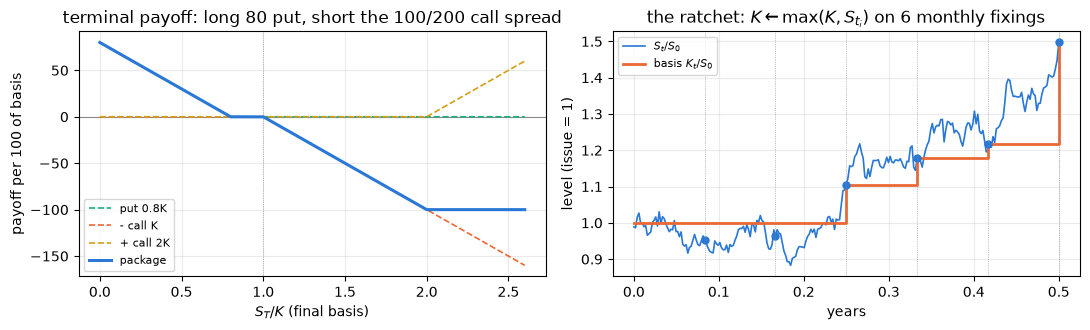

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
ax = axes[0]
s = np.linspace(0.0, 2.6, 601)
ax.axhline(0, color=GRAY, lw=0.8); ax.axvline(1.0, color=GRAY, lw=0.5, ls=":")
for lab, y, c, ls in [("put 0.8K", np.maximum(K_PUT - s, 0), C3, "--"),
                      ("- call K", -np.maximum(s - K_CALL_LO, 0), C2, "--"),
                      ("+ call 2K", np.maximum(s - K_CALL_HI, 0), C5, "--")]:
    ax.plot(s, 100 * y, ls, color=c, lw=1.2, label=lab)
ax.plot(s, 100 * package_payoff(s, 1.0), color=C1, lw=2.2, label="package")
ax.set(xlabel="$S_T / K$ (final basis)", ylabel="payoff per 100 of basis",
       title="terminal payoff: long 80 put, short the 100/200 call spread")
ax.legend(fontsize=8, loc="lower left"); ax.grid(alpha=0.25)

ax = axes[1]
rng = np.random.default_rng(4)
t = np.linspace(0, 0.5, 253)
path = np.exp(np.cumsum(rng.normal(0.0004, 0.017, len(t))) - 0.0004)
fix = np.arange(1, 7) / 12.0
fi = np.searchsorted(t, fix)
basis = np.maximum.accumulate(np.concatenate([[1.0], path[fi]]))
ax.plot(t, path, color=C1, lw=1.2, label="$S_t / S_0$")
ax.step(np.concatenate([[0.0], fix]), basis, where="post", color=C2, lw=2,
        label="basis $K_t / S_0$")
ax.plot(fix, path[fi], "o", color=C1, ms=5)
for x in fix:
    ax.axvline(x, color=GRAY, lw=0.5, ls=":")
ax.set(xlabel="years", title="the ratchet: $K \\leftarrow \\max(K, S_{t_i})$ on 6 monthly fixings",
       ylabel="level (issue = 1)")
ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout()

**Where the path dependence lives.** Only the first six months. After
$t_6$ the contract is a European package on a *known* basis, so the whole
problem factorises as

$$V_0 \;=\; D(0,t_6)\;\mathbb{E}\Big[\, T\big(S_{t_6},\, K_{t_6}\big) \Big],
\qquad K_{t_6} = \max(S_0, S_{1/12},\dots,S_{1/2}),$$

with $T(S,K)$ the 5.5y European value — an *exact*, precomputable function
of two variables. That observation is the hybrid engine in section 4, and it
is also why a deterministic PDE reference exists at all: the ratchet couples
the $K$ axis only on six dates, so the reference is $n_K$ independent 1-D
Crank-Nicolson solves sharing one tridiagonal operator, relabelled
$V(t_i^-,S,K) = V(t_i^+,S,\max(K,S))$ at each fixing.

## 2. Local-vol calibration

**The 8-pillar surface is not enough.** `vol_pca.surface`'s TTM pillars top
out at 1.0y and the product runs 6y, so the calibration input is built
straight from the cleaned raw rows (`load_term_surfaces` → `TermSurface`):
~17 quoted terms per date out to ~9.4y, moneyness still the 13 quoted
columns through the house cubic spline.

Total implied variance is assembled **at fixed log-forward-moneyness**
$y = \log(K/F_\tau)$ — the variable Dupire's calendar derivative is taken in.
For each $y$ the per-term moneyness $m_j = 100\,e^{y}F(\tau_j)/S$ is read off
term $j$'s own smile, giving exact knots $w_j = \sigma_j^2\tau_j$, and
$w(\cdot,y)$ is a shape-preserving **PCHIP** through those knots plus the
exact $w(0,y)=0$ anchor (a not-a-knot cubic overshoots between the anchor and
the first ~1-month term and manufactures $\partial_\tau w < 0$ — calendar
arbitrage the interpolant invented). Then Gatheral's total-variance Dupire,
by finite differences on a dense $(\tau, y)$ grid of 120 × 141 nodes
($\tau$ geometrically spaced $1/365 \to 6.05$y, $y \in [-3,3]$):

$$\sigma_{\rm loc}^2 = \frac{\partial_\tau w}
{1 - \frac{y}{w}\partial_y w + \frac14\!\left(-\frac14 - \frac1w + \frac{y^2}{w^2}\right)(\partial_y w)^2 + \frac12 \partial^2_{yy} w}$$

with local variance floored at $(0.05)^2$ and local vol capped at 4× that
maturity's ATM implied vol.

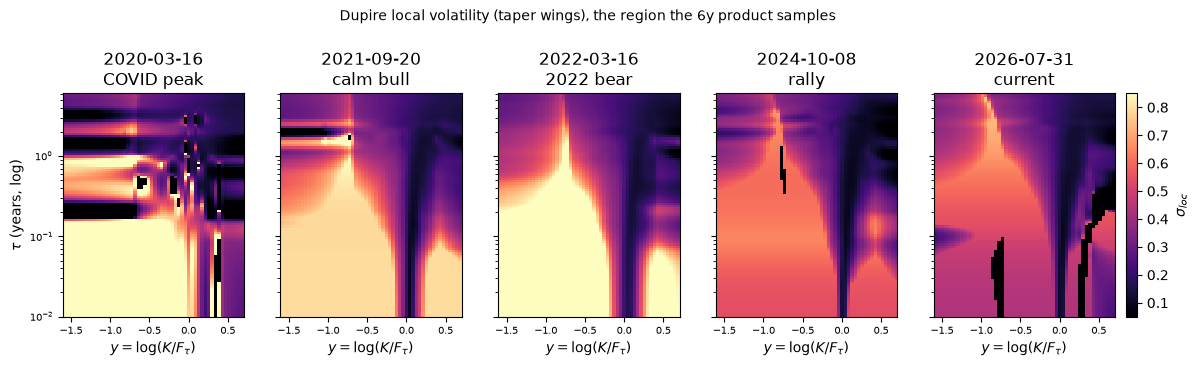

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(14, 2.9), sharey=True)
for ax, d in zip(axes, DATES):
    z = LV[(d, "taper")]
    taus, ys, sig = z["taus"], z["ys"], z["sig"]
    m = (ys > -1.6) & (ys < 0.7)
    pc = ax.pcolormesh(ys[m], taus, sig[:, m], cmap="magma", vmin=0.05, vmax=0.85,
                       shading="nearest")
    ax.set(xlabel="$y=\\log(K/F_\\tau)$", yscale="log", ylim=(0.01, 6.05),
           title=f"{d}\n{REGIME[d]}")
    ax.tick_params(labelsize=7)
axes[0].set_ylabel("$\\tau$ (years, log)")
fig.colorbar(pc, ax=axes, fraction=0.02, pad=0.01, label="$\\sigma_{loc}$")
fig.suptitle("Dupire local volatility (taper wings), the region the 6y product samples", y=1.17, fontsize=10)
plt.show()

In [4]:
t = calib[calib.wing == "taper"].set_index("date")
out = pd.DataFrame({
    "spot": t["spot"].round(0), "terms": t["n_terms"], "max term (y)": t["tau_max"].round(2),
    "floor %": t["pct_floor"].round(2), "cap %": t["pct_cap"].round(1),
    "calendar-arb nodes": t["n_calendar_arb"], "butterfly-arb nodes": t["n_bfly_arb"],
    "sig max": t["sig_max"].round(2),
    "vol-pt err mean (all tau)": t["err_mean"].round(3),
    "vol-pt err p95 (all tau)": t["err_p95"].round(2),
    "vol-pt err mean (tau>=0.5)": t["err_mean_far"].round(3),
    "vol-pt err max (tau>=0.5)": t["err_max_far"].round(3)})
print("calibration quality, headline (taper) wing — 16,920 grid nodes per date")
print(out.to_string())

calibration quality, headline (taper) wing — 16,920 grid nodes per date
              spot  terms  max term (y)  floor %  cap %  calendar-arb nodes  butterfly-arb nodes  sig max  vol-pt err mean (all tau)  vol-pt err p95 (all tau)  vol-pt err mean (tau>=0.5)  vol-pt err max (tau>=0.5)
date                                                                                                                                                                                                                 
2020-03-16  2386.0     17          9.77    11.00    0.6                1691                  130     3.24                      0.789                      1.95                       0.859                      4.188
2021-09-20  4358.0     17          9.25     2.51   28.6                 411                    2     0.85                      0.245                      1.09                       0.067                      0.284
2022-03-16  4358.0     17          9.77     2.57   28.2                 

**Reading the table honestly.** Two guards fire and both are reported, not
hidden:

* **Floor** ($\sigma_{\rm loc}^2 < 0.05^2$, or a non-positive Dupire
  numerator/denominator): 2.5–11% of nodes. These sit in the far wings and,
  on 2020-03-16, also inside the quoted window — the COVID surface carries
  genuine calendar and butterfly violations (1,691 calendar-arb and 130
  butterfly-arb nodes), which no local-vol model can reproduce. This is the
  same crash-surface pathology the rainbow thread already documented from
  the density side.
* **Cap** ($\sigma_{\rm loc} > 4\sigma_{\rm ATM}(\tau)$): 0.6–45% of nodes,
  overwhelmingly at $\tau < 0.2$y. Dupire is genuinely ill-conditioned there:
  a 3-week smile that runs from 85% vol at 50-moneyness to 12% ATM makes the
  denominator a small residual of large cancelling terms. The 6y product's
  fixings are monthly, so this region carries almost no weight — and the
  repricing error confirms it (mean 0.06–0.14 vol points for $\tau \ge 0.5$
  on the four non-COVID dates, versus 0.15–0.73 including the short end).

Refining the grid does **not** move these numbers: $n_y$ from 141 to 601
changes the $\tau \ge 0.5$ mean error by <0.05 vol points. The residual is
data, not discretisation.

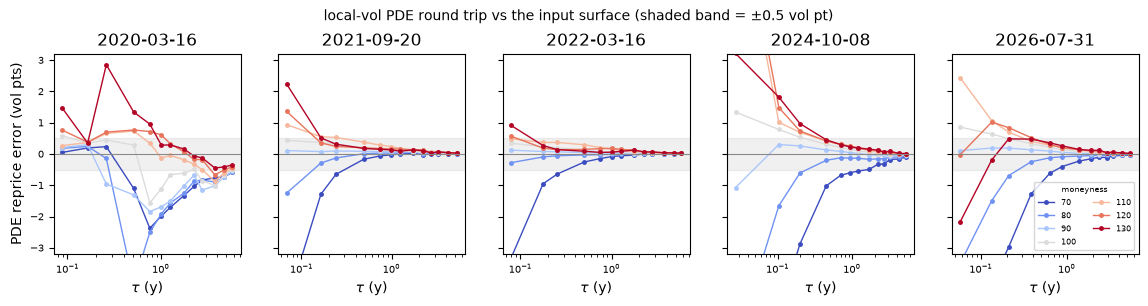

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(14, 2.6), sharey=True)
for ax, d in zip(axes, DATES):
    x = repr_[(repr_.date == d) & (repr_.wing == "taper")]
    p = x.pivot(index="tau", columns="mon", values="d_vol_pts")
    for j, m in enumerate(p.columns):
        ax.plot(p.index, p[m], "-o", ms=2.5, lw=1,
                color=plt.cm.coolwarm(j / (len(p.columns) - 1)), label=f"{int(m)}")
    ax.axhline(0, color=GRAY, lw=0.8); ax.axhspan(-0.5, 0.5, color=GRAY, alpha=0.12)
    ax.set(xscale="log", xlabel="$\\tau$ (y)", ylim=(-3.2, 3.2), title=f"{d}")
    ax.tick_params(labelsize=7)
axes[0].set_ylabel("PDE reprice error (vol pts)")
axes[-1].legend(fontsize=6, ncol=2, title="moneyness", title_fontsize=6, loc="lower right")
fig.suptitle("local-vol PDE round trip vs the input surface (shaded band = $\\pm$0.5 vol pt)",
             y=1.05, fontsize=10)
plt.show()

### The 200%-of-basis wing — a real pricing input, and the reason for the default

The $2K$ call strike sits **outside** the quoted 50–150 moneyness range at
every maturity (at 6y on 2026-07-31, $2K$ is 200 moneyness = $y = +0.43$
while the 150 column is only $y = +0.13$), so the extrapolation convention
prices it. Two conventions:

* `clamp` — flat implied vol in strike beyond the edges (the house
  `grid_lookup` convention, and the spec's stated baseline);
* `taper` — continue with the smile's edge slope, exponentially tapered to a
  bounded asymptote (rainbow.py's `implied_marginal` convention).

**The measurement picks the taper, and not because of the 200 call.** The
flat clamp leaves a *kink* in $\sigma(y)$ exactly at the 50/150 join; Dupire's
$\partial^2_{yy}w$ reads that kink as local butterfly arbitrage (denominator
< 0 — 90–255 nodes on every date, at maturities all the way out to 6y), the
guard floors $\sigma_{\rm loc}$ in a band where the long-dated put wing still
has vega, and the round trip degrades from ~0.06–0.14 to ~0.31–0.42 vol
points, with individual 5.4y/70-moneyness errors near −2 points. The same
clamp pathology is already on record in `rainbow.py` from the density side
("teleports a 2–3% Dirac of mass"). Both conventions are calibrated and
priced on every date below; the taper is the headline.

In [6]:
w = wing.pivot(index="date", columns="wing")
t = pd.DataFrame({
    "reset value, taper": w[("reset", "taper")].round(4),
    "reset value, clamp": w[("reset", "clamp")].round(4),
    "taper - clamp": (w[("reset", "taper")] - w[("reset", "clamp")]).round(4),
    "200-call leg, taper": w[("call_200", "taper")].round(4),
    "200-call leg, clamp": w[("call_200", "clamp")].round(4),
    "200-call vol, taper": w[("vol_200", "taper")].round(4),
    "200-call vol, clamp": w[("vol_200", "clamp")].round(4),
    "LV-vs-surface gap, taper": (w[("frozen_pde", "taper")] - w[("frozen_surface", "taper")]).round(4),
    "LV-vs-surface gap, clamp": (w[("frozen_pde", "clamp")] - w[("frozen_surface", "clamp")]).round(4)})
print("wing sensitivity, newly-issued package, per 100 of basis")
print(t.to_string())
print()
print("The last two rows are the cleanest verdict: with the taper the LV PDE reprices the")
print("frozen-basis European package to within 0.000-0.025 of the direct surface read; with the")
print("clamp it is off by 0.25-0.59 (the floored butterfly band in the put wing).")

wing sensitivity, newly-issued package, per 100 of basis
            reset value, taper  reset value, clamp  taper - clamp  200-call leg, taper  200-call leg, clamp  200-call vol, taper  200-call vol, clamp  LV-vs-surface gap, taper  LV-vs-surface gap, clamp
date                                                                                                                                                                                                     
2020-03-16              9.1272              8.9477         0.1795               1.4442               2.2551               0.1912               0.2113                   -0.0246                   -0.5884
2021-09-20             -2.2611             -2.2453        -0.0158               0.8829               1.4086               0.1624               0.1785                   -0.0012                   -0.4444
2022-03-16             -6.8588             -6.5991        -0.2597               1.0762               1.9174               0.1555       

## 3. Plain CPU Monte Carlo — how fast does the obvious thing converge?

The baseline estimator: pseudo-random (numpy PCG64) **log-Euler** on a fixed
grid that contains every fixing and the maturity *exactly* (each inter-fixing
segment is subdivided on its own, so the fixings are nodes by construction
rather than by floating-point luck),

$$\ln S_{k+1} = \ln S_k + \big(\ln F_{k+1} - \ln F_k\big) - \tfrac12\sigma_k^2\Delta_k + \sigma_k\sqrt{\Delta_k}\,Z_k,
\qquad \sigma_k = \sigma_{\rm loc}(t_k, S_k)$$

with $\sigma_{\rm loc}$ read bilinearly off the calibration grid. Using the
*exact* forward log-increment as the drift makes $S/F$ an exact martingale
under the scheme (each $\sigma_k$ is $\mathcal F_k$-measurable), so
$\mathbb E[S_T] = F(T)$ carries no discretisation bias at all — the martingale
check in section 6 is pure MC error.

Step ladder: monthly (72 steps), weekly (310), daily (1512).

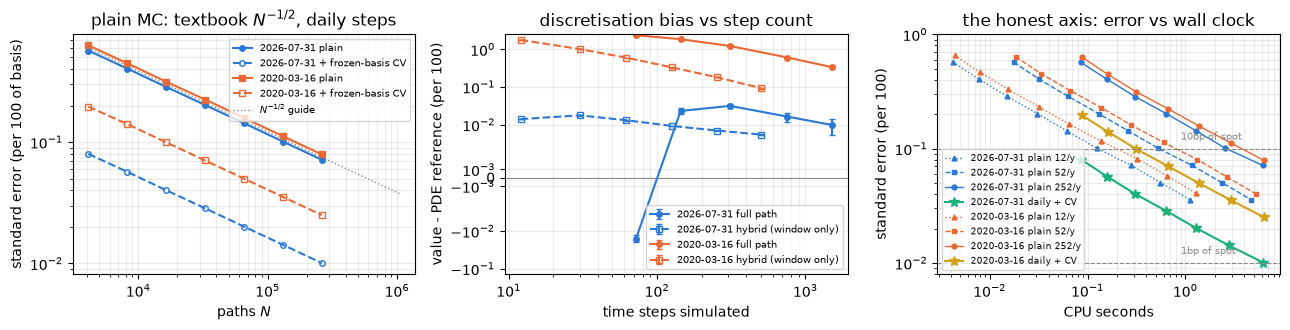

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
ax = axes[0]
for c, (d, mk) in zip((C1, C2), zip(STUDY, ("o", "s"))):
    x = conv_c[(conv_c.date == d) & (conv_c.rung == "cpu_plain") & (conv_c.per_year == 252)]
    ax.loglog(x.n_paths, x.se_internal, mk + "-", color=c, ms=4, label=f"{d} plain")
    y = conv_c[(conv_c.date == d) & (conv_c.rung == "cpu_cv")]
    ax.loglog(y.n_paths, y.se_internal, mk + "--", color=c, ms=4, mfc="none",
              label=f"{d} + frozen-basis CV")
n0 = conv_c.n_paths.min(); s0 = 0.6
ax.loglog([n0, 1 << 20], [s0, s0 * (n0 / (1 << 20))**0.5], color=GRAY, lw=1, ls=":",
          label="$N^{-1/2}$ guide")
ax.set(xlabel="paths $N$", ylabel="standard error (per 100 of basis)",
       title="plain MC: textbook $N^{-1/2}$, daily steps")
ax.legend(fontsize=7); ax.grid(alpha=0.25, which="both")

ax = axes[1]
for c, d in zip((C1, C2), STUDY):
    b = bias[(bias.date == d) & (bias.kind == "full")]
    ref = b.ref.iloc[0]
    ax.errorbar(b.n_dim, b.pv - ref, yerr=b.se, fmt="o-", color=c, ms=4, capsize=2,
                label=f"{d} full path")
    h = bias[(bias.date == d) & (bias.kind == "hybrid")]
    ax.errorbar(h.n_dim, h.pv - h.ref.iloc[0], yerr=h.se, fmt="s--", color=c, ms=4,
                mfc="none", capsize=2, label=f"{d} hybrid (window only)")
ax.axhline(0, color=GRAY, lw=0.8)
ax.set_xscale("log"); ax.set_yscale("symlog", linthresh=0.005)
ax.set(xlabel="time steps simulated", ylabel="value - PDE reference (per 100)",
       title="discretisation bias vs step count")
ax.legend(fontsize=7); ax.grid(alpha=0.25, which="both")

ax = axes[2]
for c, d in zip((C1, C2), STUDY):
    for py, ls, mk in ((12, ":", "^"), (52, "--", "s"), (252, "-", "o")):
        x = conv_c[(conv_c.date == d) & (conv_c.rung == "cpu_plain") & (conv_c.per_year == py)]
        ax.loglog(x.secs, x.se_internal, mk + ls, color=c, ms=3.5, lw=1,
                  label=f"{d} plain {py}/y")
    y = conv_c[(conv_c.date == d) & (conv_c.rung == "cpu_cv")]
    ax.loglog(y.secs, y.se_internal, "*-", color=C3 if d == STUDY[0] else C5, ms=7,
              label=f"{d} daily + CV")
for lvl, lab in ((0.10, "10bp of spot"), (0.01, "1bp of spot")):
    ax.axhline(lvl, color=GRAY, lw=0.8, ls="--")
    ax.text(0.9, lvl * 1.2, lab, fontsize=7, color=GRAY)
ax.set_ylim(0.008, 1.0)
ax.set(xlabel="CPU seconds", ylabel="standard error (per 100)",
       title="the honest axis: error vs wall clock")
ax.legend(fontsize=6.5); ax.grid(alpha=0.25, which="both")
plt.tight_layout()

In [8]:
rows = []
for d in STUDY:
    for rung, py in (("cpu_plain", 12), ("cpu_plain", 52), ("cpu_plain", 252), ("cpu_cv", 252)):
        x = conv_c[(conv_c.date == d) & (conv_c.rung == rung) & (conv_c.per_year == py)]
        x = x.sort_values("n_paths").iloc[-1]
        for tgt, lab in ((0.10, "10bp"), (0.01, "1bp")):
            f = (x.se_internal / tgt) ** 2
            rows.append({"date": d, "rung": f"{rung} {py}/y ({int(x.n_steps)} steps)",
                         "target s.e.": lab, "paths needed": f"{x.n_paths * f:,.0f}",
                         "CPU seconds": round(x.secs * f, 1)})
t = pd.DataFrame(rows).pivot_table(index=["date", "rung"], columns="target s.e.",
                                   values=["paths needed", "CPU seconds"], aggfunc="first")
print("plain CPU MC: cost of a given standard error (extrapolated from the measured N^-1/2 line)")
print(t.to_string())

plain CPU MC: cost of a given standard error (extrapolated from the measured N^-1/2 line)
                                        CPU seconds        paths needed            
target s.e.                                    10bp    1bp         10bp         1bp
date       rung                                                                    
2020-03-16 cpu_cv 252/y (1512 steps)            0.4   40.2       16,390   1,638,951
           cpu_plain 12/y (72 steps)            0.2   21.4      175,975  17,597,458
           cpu_plain 252/y (1512 steps)         3.9  394.5      164,237  16,423,662
           cpu_plain 52/y (310 steps)           0.8   84.8      168,589  16,858,866
2026-07-31 cpu_cv 252/y (1512 steps)            0.1    6.4        2,652     265,216
           cpu_plain 12/y (72 steps)            0.1   14.2      133,971  13,397,059
           cpu_plain 252/y (1512 steps)         3.1  314.2      133,947  13,394,739
           cpu_plain 52/y (310 steps)           0.6   60.1      133,80

The control variate is the frozen-basis package payoff on the same paths,
anchored on its exact LV-PDE mean. Under **pseudo**-MC that is textbook — the
correlation is 0.990, giving a ~7× standard-error cut (≈50× in variance) for
~2% extra work. Worth stating explicitly: this does **not** contradict the
repo's 2026-08-06 negative CV verdict, which was specific to *scrambled
Sobol* — there the QMC rule has already integrated the smooth component the
control shares, so the correction only injects the control's own noise. A CV
is a pseudo-MC device.

## 4. Advanced rungs on the GPU

Three ladders, all in `vol_pca/rila_torch.py` (numpy engines stay canonical;
tests pin CRN parity):

* **(a) pseudo on device** — the same estimator as section 3, throughput
  only. Fed the CPU's normals it reproduces the CPU price to $8\times10^{-16}$
  relative in float64 and $3\times10^{-7}$ in float32.
* **(b) scrambled Sobol + Brownian bridge** — dimension = number of steps
  (1512 daily over 6y). The bridge (QuantLib/Glasserman ordering) hands the
  terminal increment to Sobol coordinate 0 and then bisects, so the leading,
  best-equidistributed coordinates carry the coarse shape of the path.
* **(c) hybrid / conditional smoothing** — simulate only the six-month
  window (daily → **126 dimensions**) and integrate the 5.5y tail *exactly*
  against the precomputed table $T(S_w, K)$, ~3s of Crank-Nicolson for 145
  basis nodes. The kinked terminal payoff is replaced by a smooth 2-D
  lookup: variance collapses **and** the QMC rate improves.

Error bars are independent scramble replicates (16–24), the repo's standard
QMC error-estimation pattern; a single scrambled-Sobol run has no usable
internal s.e.

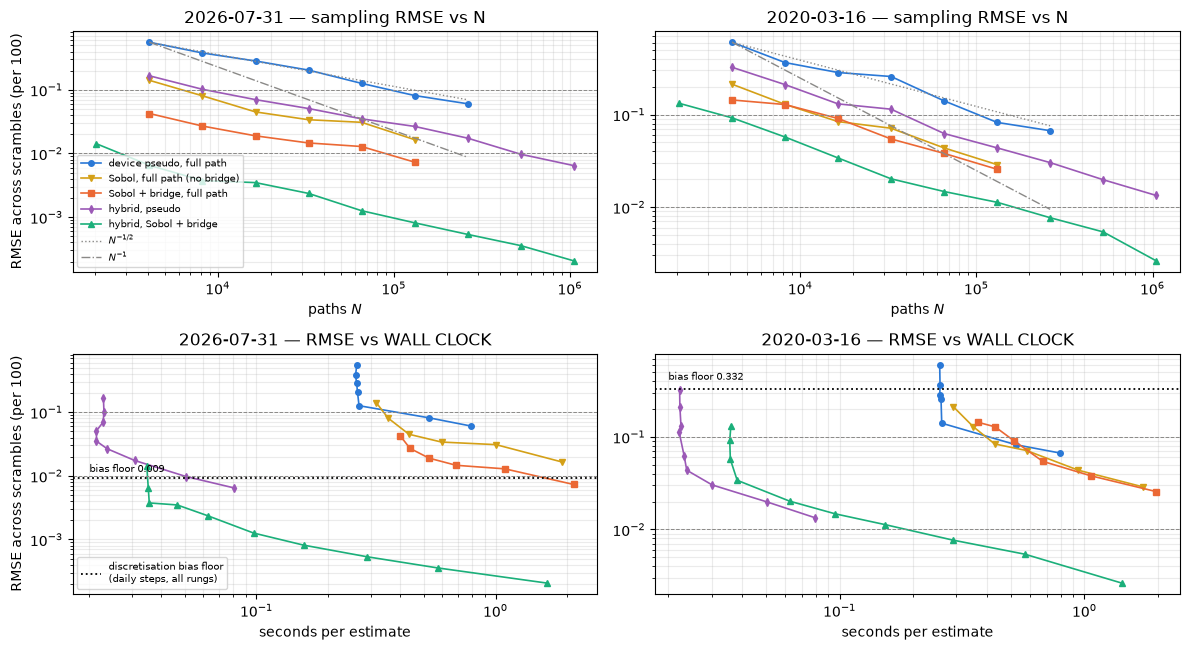

In [9]:
RUNGS = [("gpu_pseudo", "device pseudo, full path", C1, "o"),
         ("gpu_sobol", "Sobol, full path (no bridge)", C5, "v"),
         ("gpu_sobol_bb", "Sobol + bridge, full path", C2, "s"),
         ("hybrid_pseudo", "hybrid, pseudo", C4, "d"),
         ("hybrid_sobol_bb", "hybrid, Sobol + bridge", C3, "^")]
fig, axes = plt.subplots(2, 2, figsize=(12, 6.6))
for col, d in enumerate(STUDY):
    for row, (xk, xlab, ttl) in enumerate(
            [("n_paths", "paths $N$", "sampling RMSE vs N"),
             ("secs", "seconds per estimate", "RMSE vs WALL CLOCK")]):
        ax = axes[row, col]
        for key, lab, c, mk in RUNGS:
            x = conv_g[(conv_g.date == d) & (conv_g.rung == key)].sort_values("n_paths")
            ax.loglog(x[xk], x.rmse, mk + "-", color=c, ms=4, lw=1.2,
                      label=lab if (row == 0 and col == 0) else None)

        if row == 0:
            x = conv_g[(conv_g.date == d) & (conv_g.rung == "gpu_pseudo")].sort_values("n_paths")
            ax.loglog(x.n_paths, x.rmse.iloc[0] * (x.n_paths / x.n_paths.iloc[0])**-0.5,
                      ":", color=GRAY, lw=1, label="$N^{-1/2}$" if col == 0 else None)
            ax.loglog(x.n_paths, x.rmse.iloc[0] * (x.n_paths / x.n_paths.iloc[0])**-1.0,
                      "-.", color=GRAY, lw=1, label="$N^{-1}$" if col == 0 else None)
        for lvl in (0.10, 0.01):
            ax.axhline(lvl, color=GRAY, lw=0.7, ls="--")
        if row == 1:
            # every rung here runs 252 steps/y, so they share one bias floor
            bl = abs(conv_g[(conv_g.date == d)
                            & (conv_g.rung == "hybrid_sobol_bb")].err_vs_pde.iloc[-1])
            ax.axhline(bl, color="k", lw=1.3, ls=":",
                       label="discretisation bias floor\n(daily steps, all rungs)"
                       if col == 0 else None)
            ax.annotate(f"bias floor {bl:.3f}", (0.02, bl * 1.25), fontsize=7)
        ax.set(xlabel=xlab, ylabel="RMSE across scrambles (per 100)" if col == 0 else None,
               title=f"{d} — {ttl}")
        ax.grid(alpha=0.25, which="both")
axes[0, 0].legend(fontsize=7, loc="lower left")
axes[1, 0].legend(fontsize=7, loc="lower left")
plt.tight_layout()

In [10]:
CPU1BP = {d: conv_c[(conv_c.date == d) & (conv_c.rung == "cpu_plain")
                    & (conv_c.per_year == 252)].sort_values("n_paths").iloc[-1]
          for d in STUDY}
fits = []
for d in STUDY:
    cpu = CPU1BP[d]
    cpu_s = cpu.secs * (cpu.se_internal / 0.01) ** 2          # plain CPU baseline
    for key, lab, _, _ in RUNGS:
        x = conv_g[(conv_g.date == d) & (conv_g.rung == key)].sort_values("n_paths")
        a = np.polyfit(np.log(x.n_paths), np.log(x.rmse), 1)[0]
        b = np.polyfit(np.log(x.secs), np.log(x.rmse), 1)[0]
        hit = x[x.rmse <= 0.01]                               # measured, not fitted
        if len(hit):
            n1, s1, tag = f"{int(hit.iloc[0].n_paths):,}", hit.iloc[0].secs, ""
        else:
            f_ = (0.01 / x.iloc[-1].rmse) ** (1.0 / a)        # extrapolate the fit
            n1, s1, tag = f"{x.iloc[-1].n_paths * f_:,.0f}*", x.iloc[-1].secs * f_, "*"
        fits.append({"date": d, "rung": lab, "dims": int(x.iloc[-1].n_dim),
                     "RMSE ~ N^a: a": round(a, 3), "RMSE ~ t^b: b": round(b, 3),
                     "RMSE @ N=2^16": round(float(x[x.n_paths == 65536].rmse.iloc[0]), 5),
                     "s @ N=2^16": round(float(x[x.n_paths == 65536].secs.iloc[0]), 3),
                     "N to 1bp": n1, "s to 1bp": round(s1, 3),
                     "x faster than CPU": f"{cpu_s / s1:,.0f}x"})
t = pd.DataFrame(fits)
print("convergence exponents and the cost of 1bp of spot SAMPLING error (bias excluded)")
print(t.to_string(index=False))
print()
print("N/s to 1bp are the first MEASURED ladder point at or below 1bp; a * marks an")
print("extrapolation along the fitted rate because the rung never got there. Seconds are")
print("per estimate on an RTX 4070 Laptop and carry a ~0.02-0.04s kernel-launch floor, so")
print("the fastest rungs are launch-bound, not throughput-bound. CPU baseline = plain")
print("pseudo MC with daily steps: " + ", ".join(
    f"{d} {CPU1BP[d].secs * (CPU1BP[d].se_internal / 0.01) ** 2:.0f}s" for d in STUDY) + ".")

convergence exponents and the cost of 1bp of spot SAMPLING error (bias excluded)
      date                         rung  dims  RMSE ~ N^a: a  RMSE ~ t^b: b  RMSE @ N=2^16  s @ N=2^16   N to 1bp  s to 1bp x faster than CPU
2026-07-31     device pseudo, full path  1512         -0.544         -1.486        0.12643       0.269 7,146,969*    21.590               15x
2026-07-31 Sobol, full path (no bridge)  1512         -0.572         -1.004        0.03090       1.005   315,292*     4.559               69x
2026-07-31    Sobol + bridge, full path  1512         -0.464         -0.896        0.01287       1.095    131,072     2.122              148x
2026-07-31               hybrid, pseudo   126         -0.564         -1.900        0.03504       0.021    524,288     0.051            6,198x
2026-07-31       hybrid, Sobol + bridge   126         -0.639         -0.952        0.00126       0.097      4,096     0.035            8,914x
2020-03-16     device pseudo, full path  1512         -0.530       

Two things the chart says out loud:

1. **QMC works here, but on the raw path it buys a *constant*, not a
   rate.** Plain pseudo sits on $N^{-1/2}$ ($a = -0.54$/$-0.53$). Scrambled
   Sobol on the 1512-dimensional path is 4× better at $N = 2^{12}$ and the
   Brownian bridge makes it 13× better — yet the fitted exponents stay near
   $-0.5$ ($-0.46$ to $-0.57$): 1512 dimensions is far past where Sobol's
   equidistribution helps asymptotically, so the bridge is buying a smaller
   constant by front-loading the variance into the well-behaved leading
   coordinates. Only when the dimension actually collapses does the *rate*
   move: the hybrid's 126-dimensional, smooth-payoff estimator fits
   $a = -0.64$/$-0.60$. And high-dimensional QMC is not free — generating
   $N \times 1512$ scrambled Sobol points is about half the wall clock of the
   full-path rung, which is exactly why the *error-vs-seconds* panel is the
   honest one.
2. **The hybrid wins on both axes at once.** Dropping to 126 dimensions and
   replacing the kinked payoff by a smooth table shrinks the constant *and*
   steepens the rate — and it is ~12× cheaper per path because it simulates
   126 steps instead of 1512. At $N = 2^{16}$ on 2026-07-31 it is 100× more
   accurate than device pseudo **and 2.8× faster**; it clears 1bp of spot at
   4,096 paths in 0.035 s against 314 s for plain CPU Monte Carlo. The
   one-off tail table costs ~3 seconds of Crank-Nicolson and is reusable
   across every path count and every scramble.

The bias panel in section 3 is the other half of the story: sampling error is
not the only error. At daily steps the log-Euler bias is ~0.006 per 100 on
the current surface but ~0.33 on the COVID surface, where $\sigma_{\rm loc}$
reaches 324% — there the **step size, not the path count, is the binding
constraint**, and the hybrid's own bias ladder (its window is the only part
discretised) shows the same.

## 5. Values

The value of record is the **deterministic PDE reference** (`pde_reset_price`,
145 basis nodes × 1201 log-spot nodes × 320 steps/yr ≈ 3 s/state). Its own
grid ladder converges onto the flat-vol backward-recursion oracle to
$5\times10^{-5}$ per 100 of basis, and this production config sits 0.0015 from
the oracle (0.15bp of spot); on the COVID surface the ladder is stable to
~0.002. The GPU hybrid column is the *engine* being benchmarked against it.

In [11]:
new = states[(states.engine == "hybrid") & (states.resets_left == 6)].set_index("date")
t = pd.DataFrame({
    "spot": new["spot"].round(0),
    "reset value (per 100)": new["pde"].round(3),
    "frozen basis (per 100)": new["frozen_pde"].round(3),
    "reset premium (per 100)": new["reset_prem_pde"].round(3),
    "premium, CRN MC": new["reset_prem_mc"].round(3),
    "premium se": new["reset_prem_se"].round(4),
    "$1M notional value ($)": (new["pde"] / 100 * NOTIONAL).round(0),
    "$1M premium ($)": (new["reset_prem_pde"] / 100 * NOTIONAL).round(0),
    "GPU hybrid": new["gpu"].round(3),
    "hybrid - PDE": (new["gpu"] - new["pde"]).round(3),
    "CPU 2^16 MC": new["cpu"].round(3), "CPU se": new["cpu_se"].round(3)})
t.insert(0, "regime", [REGIME[d] for d in t.index])
print("NEWLY ISSUED (K = S, 6y, six resets ahead) — per 100 of basis, signed")
print(t.to_string())

NEWLY ISSUED (K = S, 6y, six resets ahead) — per 100 of basis, signed
                regime    spot  reset value (per 100)  frozen basis (per 100)  reset premium (per 100)  premium, CRN MC  premium se  $1M notional value ($)  $1M premium ($)  GPU hybrid  hybrid - PDE  CPU 2^16 MC  CPU se
date                                                                                                                                                                                                                       
2020-03-16  COVID peak  2386.0                  9.127                  -3.230                   12.358           12.649      0.0008                 91272.0         123576.0       9.461         0.334        9.440   0.159
2021-09-20   calm bull  4358.0                 -2.261                  -7.582                    5.321            5.344      0.0001                -22611.0          53207.0      -2.237         0.024       -2.272   0.153
2022-03-16   2022 bear  4358.0                 -6.

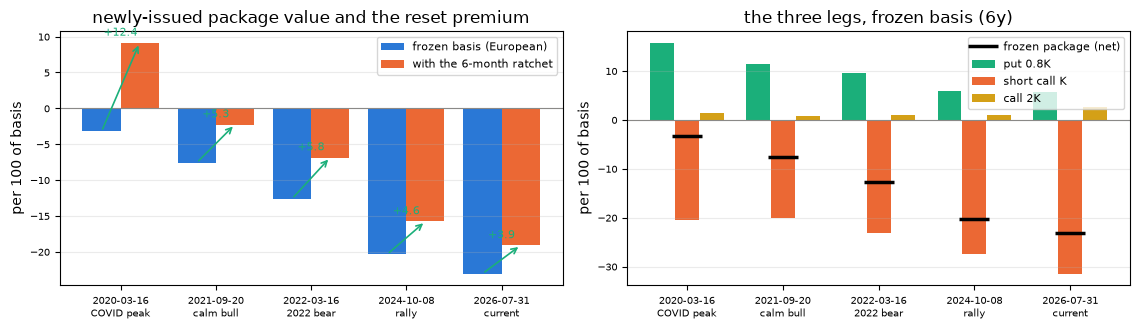

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))
x = np.arange(len(DATES))
ax = axes[0]
n = new.loc[DATES]
ax.axhline(0, color=GRAY, lw=0.8)
ax.bar(x - 0.2, n["frozen_pde"], 0.4, color=C1, label="frozen basis (European)")
ax.bar(x + 0.2, n["pde"], 0.4, color=C2, label="with the 6-month ratchet")
for i, (a, b) in enumerate(zip(n["frozen_pde"], n["pde"])):
    ax.annotate("", (i + 0.2, b), (i - 0.2, a),
                arrowprops=dict(arrowstyle="->", color=C3, lw=1.2))
    ax.text(i, max(a, b) + 1.0, f"+{b - a:.1f}", ha="center", fontsize=8, color=C3)
ax.set(xticks=x, xticklabels=[f"{d}\n{REGIME[d]}" for d in DATES],
       ylabel="per 100 of basis", title="newly-issued package value and the reset premium")
ax.tick_params(labelsize=7.5); ax.legend(fontsize=8); ax.grid(alpha=0.25, axis="y")

ax = axes[1]
lg = wing[wing.wing == "taper"].set_index("date").loc[DATES]
ax.axhline(0, color=GRAY, lw=0.8)
for off, (lab, col, c) in zip((-0.26, 0.0, 0.26),
                              (("put 0.8K", "put_80", C3), ("short call K", "call_100", C2),
                               ("call 2K", "call_200", C5))):
    ax.bar(x + off, lg[col], 0.25, color=c, label=lab)
ax.plot(x, lg["frozen_pde"], "k_", ms=22, mew=2.5, label="frozen package (net)")
ax.set(xticks=x, xticklabels=[f"{d}\n{REGIME[d]}" for d in DATES],
       ylabel="per 100 of basis", title="the three legs, frozen basis (6y)")
ax.tick_params(labelsize=7.5); ax.legend(fontsize=8); ax.grid(alpha=0.25, axis="y")
plt.tight_layout()

The sign flips with the regime, and it is the *put* that does it: on
2020-03-16 a 6y 80%-strike put on a crashed spot with 40%+ vol is worth 15.7
points of basis, enough to overwhelm the 20.4 points collected on the short
100 call, and the ratchet — worth **12.4 points** in that volatility — pushes
the package firmly positive. On 2026-07-31, after a long rally, the put is
worth 5.8 against 31.5 collected, and the ratchet only 3.9. The reset premium
is monotone in the volatility regime and is always positive: the ratchet can
only ever raise the basis, which shortens the short call and lengthens the
put.

In [13]:
mid = states[(states.engine == "hybrid") & (states.resets_left > 0) & (states.resets_left < 6)]
t = mid.pivot_table(index=["date"], columns=["resets_left", "k_over_s"], values="pde").round(3)
t2 = mid.pivot_table(index=["date"], columns=["resets_left", "k_over_s"],
                     values="reset_prem_pde").round(3)
print("SEASONED MID-WINDOW — value per 100 of basis (PDE reference)")
print(t.to_string())
print()
print("...of which the remaining reset premium")
print(t2.to_string())
print()
print("worst |hybrid - PDE| over the 30 simulated states:",
      round((mid['gpu'] - mid['pde']).abs().max(), 3), "per 100")

SEASONED MID-WINDOW — value per 100 of basis (PDE reference)
resets_left       2                       4                
k_over_s       0.95    1.00    1.08    0.95    1.00    1.08
date                                                       
2020-03-16    4.542   5.445   7.264   7.297   7.865   9.099
2021-09-20   -5.731  -4.884  -1.620  -4.013  -3.438  -1.184
2022-03-16  -10.751  -9.594  -6.262  -8.895  -8.032  -5.636
2024-10-08  -18.995 -17.613 -13.595 -17.742 -16.583 -13.488
2026-07-31  -22.214 -20.764 -16.536 -21.107 -19.850 -16.559

...of which the remaining reset premium
resets_left       2                     4               
k_over_s       0.95   1.00   1.08    0.95    1.00   1.08
date                                                    
2020-03-16   11.897  9.030  5.438  14.451  11.273  7.125
2021-09-20    5.745  2.567  0.136   7.507   4.082  0.662
2022-03-16    5.731  2.841  0.369   7.646   4.500  1.129
2024-10-08    5.093  2.254  0.143   6.529   3.540  0.579
2026-07-31    4.138

In [14]:
post = states[states.engine == "surface"]
t = post.pivot_table(index=["date", "ttm"], columns="k_over_s", values="surface").round(3)
print("SEASONED POST-WINDOW (r=0, basis frozen) — DIRECT SURFACE READS, no simulation")
print(t.to_string())
print()
g = (post["pde"] - post["surface"]).abs()
print(f"LV-PDE vs direct-read gap over all {len(post)} post-window states: "
      f"mean {g.mean():.4f}, max {g.max():.4f} per 100 of basis "
      f"(max on {post.loc[g.idxmax(), 'date']}, ttm {post.loc[g.idxmax(), 'ttm']}y) "
      f"— this is the calibration error, measured end to end on the product itself")

SEASONED POST-WINDOW (r=0, basis frozen) — DIRECT SURFACE READS, no simulation
k_over_s          0.75    0.90    1.00    1.10
date       ttm                                
2020-03-16 1.0 -34.363 -15.471  -6.133   1.411
           3.0 -31.236 -14.828  -5.506   2.164
           5.5 -25.725 -11.680  -3.755   2.969
2021-09-20 1.0 -34.032 -13.731  -4.323   2.128
           3.0 -33.452 -14.750  -5.683   1.224
           5.5 -31.472 -15.867  -7.371  -0.363
2022-03-16 1.0 -35.251 -15.026  -5.655   1.067
           3.0 -37.117 -18.766  -9.479  -2.239
           5.5 -35.611 -20.829 -12.327  -5.157
2024-10-08 1.0 -37.540 -16.645  -6.953  -0.359
           3.0 -42.881 -23.093 -13.226  -5.563
           5.5 -42.744 -28.443 -19.572 -11.953
2026-07-31 1.0 -37.742 -16.846  -7.264  -0.765
           3.0 -43.519 -24.714 -14.954  -7.296
           5.5 -43.283 -30.272 -22.087 -14.833

LV-PDE vs direct-read gap over all 60 post-window states: mean 0.0586, max 0.5334 per 100 of basis (max on 2020-03-16, tt

## 6. Validation

Everything below is live (a few seconds), not read from cache.

In [15]:
import torch
from vol_pca.local_vol import (flat_local_vol, flat_reset_oracle, flat_term_surface,
                               mc_time_grid, pde_reset_price, pde_package,
                               price_rila_mc, european_package_surface, rila_value)
from vol_pca.rila_torch import make_tail_table, prepare, rila_price_torch, rila_replicates

ts = load_term_surfaces("SPX_volSurface.csv", ["2026-07-31"])["2026-07-31"]
lv = dupire_local_vol(ts)
st = rila_state(ts, 6, 1.0)
rows = []

# 1. flat-vol reset oracle vs the PDE reference and vs plain MC
vol, r_, q_ = 0.22, 0.03, 0.015
fts, flv = flat_term_surface(vol=vol, spot=100.0, rate=r_, div=q_), flat_local_vol(
    vol=vol, spot=100.0, rate=r_, div=q_)
fst = rila_state(fts, 6, 1.0)
orc = 100 * flat_reset_oracle(vol, r_, q_, fst.ttm, fst.fixings)
fpde = per_100(pde_reset_price(flv, fst, n_k=97, n_x=801, per_year=200)["pv"], fst.basis)
rows.append(("flat-vol backward-recursion oracle vs PDE reference", f"{orc:.5f}",
             f"{fpde:.5f}", f"{fpde - orc:+.5f}", "per 100"))

# 2. CPU/GPU CRN parity on identical normals
t_grid, fix_idx = mc_time_grid(st, 12)
nrm = np.random.default_rng(7).standard_normal((4096, len(t_grid) - 1))
cpu = price_rila_mc(lv, st, n_paths=4096, t_grid=t_grid, fix_idx=fix_idx, normals=nrm)["pv"]
for dt_, nm in ((torch.float64, "fp64"), (torch.float32, "fp32")):
    g = rila_price_torch(lv, st, n_paths=4096, normals=nrm, dtype=dt_,
                         t_grid=t_grid, fix_idx=fix_idx)["pv"]
    rows.append((f"CPU vs GPU, identical normals ({nm})", f"{cpu:.6f}", f"{g:.6f}",
                 f"{abs(g / cpu - 1):.2e}", "relative"))

# 3. martingale
m = rila_price_torch(lv, st, n_paths=1 << 16, per_year=52, seed=3)
rows.append(("martingale E[S_T] vs F(T), 6y", f"{m['fwd']:.1f}", f"{m['mean_s']:.1f}",
             f"{m['mean_s'] / m['fwd'] - 1:+.2e}", "relative"))

# 4. hybrid vs full path, same step size
tab = make_tail_table(lv, st, n_k=97, n_x=801, per_year=200)
h = rila_replicates(lv, st, 1 << 14, replicates=8, prep=prepare(lv, st, 252, tab), seed0=91)
f = rila_replicates(lv, st, 1 << 14, replicates=8, prep=prepare(lv, st, 252), seed0=91)
rows.append(("hybrid (126 dims) vs full path (1512 dims), 252 steps/y",
             f"{per_100(f['pv'], st.basis):.5f} ± {per_100(f['se'], st.basis):.5f}",
             f"{per_100(h['pv'], st.basis):.5f} ± {per_100(h['se'], st.basis):.5f}",
             f"{per_100(h['pv'] - f['pv'], st.basis):+.5f}",
             f"{abs(h['pv'] - f['pv']) / np.hypot(h['se'], f['se']):.1f} sigma"))

# 5. post-window identity
pst = rila_state(ts, 0, 0.90, ttm=3.0)
out = rila_value(ts, lv, pst)
ref = european_package_surface(ts, pst.basis, pst.ttm)
rows.append(("post-window state -> direct surface read (identity)",
             f"{per_100(ref['pv'], pst.basis):.6f}", f"{per_100(out['pv'], pst.basis):.6f}",
             f"{out['pv'] - ref['pv']:.1e}", out["engine"]))

# 6. frozen basis: the tail table integrates back to the European value
eur = pde_package(lv, st.basis, st.ttm, n_x=801, per_year=200)
frz = rila_replicates(lv, st, 1 << 16, replicates=8, prep=prepare(lv, st, 252, tab),
                      reset=False, seed0=71)
rows.append(("ratchet off: hybrid vs LV-PDE European (tower property)",
             f"{per_100(eur, st.basis):.4f}",
             f"{per_100(frz['pv'], st.basis):.4f} ± {per_100(frz['se'], st.basis):.4f}",
             f"{per_100(frz['pv'] - eur, st.basis):+.4f}", "per 100"))

print(pd.DataFrame(rows, columns=["check", "reference", "engine", "gap", "unit"]).to_string(index=False))
print()
print("Row 1 runs a coarse PDE config (97 x 801 x 200/y) to keep this cell fast; the")
print("production config (145 x 1201 x 320/y) sits 0.0015 from the oracle and the grid")
print("ladder converges onto it to 5e-5. The CPU frozen-basis MC and the flat-vol MC")
print("oracle checks live in tests/test_local_vol.py and tests/test_rila_torch.py.")
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available()
      else "CUDA NOT AVAILABLE — torch rungs ran on CPU, timings are not GPU-verified")

                                                  check           reference              engine       gap      unit
    flat-vol backward-recursion oracle vs PDE reference            -6.44561            -6.44767  -0.00206   per 100
                   CPU vs GPU, identical normals (fp64)        -1424.301517        -1424.301517  7.77e-16  relative
                   CPU vs GPU, identical normals (fp32)        -1424.301517        -1424.301899  2.68e-07  relative
                          martingale E[S_T] vs F(T), 6y              9555.5              9556.1 +6.28e-05  relative
hybrid (126 dims) vs full path (1512 dims), 252 steps/y -19.09677 ± 0.00762 -19.10217 ± 0.00154  -0.00540 0.7 sigma
    post-window state -> direct surface read (identity)          -24.713555          -24.713555   0.0e+00   surface
ratchet off: hybrid vs LV-PDE European (tower property)            -23.0542   -23.0545 ± 0.0004   -0.0003   per 100

Row 1 runs a coarse PDE config (97 x 801 x 200/y) to keep this cell fas

## 7. Verdict

**How fast does plain MC converge?** Exactly as advertised and no faster:
$N^{-1/2}$ with no surprises, because the payoff is continuous and the
fixings sit on grid nodes. On the current surface the newly-issued package
costs about **3 CPU seconds to a 10bp-of-spot standard error and ~5 CPU
minutes to 1bp** with daily steps (weekly steps have the same variance at
one-fifth the cost — ~1 minute to 1bp — but five times the discretisation
bias). The COVID surface is ~12% noisier and correspondingly slower. The
frozen-basis control variate, anchored on the exact LV-PDE mean, is the
cheapest single upgrade available on CPU: correlation 0.990, a ~7× standard
error cut, **1bp in ~6 CPU seconds** instead of 5 minutes. It is a
pseudo-MC device only — it does not, and should not, be combined with
scrambled Sobol.

**What do the advanced rungs buy?** Measured on 2026-07-31, as wall clock to
a 1bp-of-spot sampling error (plain CPU MC with daily steps = 314 s):

| rung | dims | s to 1bp | vs CPU |
|---|---|---|---|
| device pseudo, full path | 1512 | 21.6 s* | 15× |
| Sobol, full path, no bridge | 1512 | 4.6 s* | 69× |
| Sobol + Brownian bridge, full path | 1512 | 2.1 s | 148× |
| hybrid, pseudo | 126 | 0.051 s | 6,200× |
| **hybrid, Sobol + bridge** | **126** | **0.035 s** | **8,900×** |

Moving the same estimator to the GPU is throughput and nothing else (15×).
Scrambled Sobol on the raw 1512-dimensional path buys a much better
*constant* — 13× at $N = 2^{12}$ with the bridge — but not a better exponent;
the fitted rates all stay near $N^{-1/2}$. Only the **hybrid** changes the
rate ($a = -0.64$), because collapsing to 126 dimensions and replacing the
kinked payoff by a smooth table is what QMC actually needs. Note the last two
rows sit near the ~0.02–0.04 s kernel-launch floor, so the "vs CPU" ordering
between them understates the gap: at the same $N = 2^{16}$ the Sobol+bridge
hybrid is **28× more accurate** than the pseudo hybrid at 4.6× the cost. A
starred entry is extrapolated along the fitted rate because the rung never
reached 1bp on the measured ladder.

**Is the hybrid the recommended production engine? Yes — with one caveat that
is really the headline.** The hybrid's remaining error is not sampling error;
it is the log-Euler discretisation of the six-month window, and *that* is
what should set the step budget. On the current surface daily steps leave
~0.009 per 100; on the COVID surface, where $\sigma_{\rm loc}$ reaches 324%
and the calibration itself is fighting genuine calendar/butterfly arbitrage
in the data, daily steps leave ~0.33 per 100 — fifty times more than the
sampling error at $N = 2^{18}$. On crisis surfaces the right move is to spend
the budget on steps, not paths (or, for this particular product, to skip
simulation entirely: the ratchet is coupled on only six dates, so the
deterministic PDE reference prices the whole thing in ~3 seconds and is the
value of record here).

Practical ladder for the newly-issued package on this machine:

| engine | cost | error (per 100 of basis) |
|---|---|---|
| direct surface read (post-window states) | µs | exact by definition |
| CPU plain MC, 2^16 paths, daily | 1.3 s | ±0.14 sampling + 0.009 bias |
| CPU + frozen-basis control variate | 1.3 s | ±0.020 sampling + 0.009 bias |
| GPU hybrid, 2^18 paths, daily window | 0.29 s + 3 s table | ±0.0005 sampling + 0.009 bias |
| **PDE reference** (145 K-nodes × 1201 × 320/y) | **3 s** | **~0.002, deterministic** |

Open hooks, honestly flagged: the short-maturity wings of the calibration are
capped hard (Dupire is ill-conditioned on a 3-week smile running 85%→12%) and
would need a smoothed/arbitrage-repaired smile before anyone priced a
short-dated product off this surface; the COVID date carries genuine
arbitrage the local-vol model absorbs into the floor; and the whole study
holds rates and dividends deterministic, which for a 6y contract is a
modelling choice, not a fact.

In [16]:
print(f"notebook runtime {time.time() - T0:.1f}s")

notebook runtime 12.5s
